<a href="https://colab.research.google.com/github/slustudentjli/ores5160-2025/blob/main/Final%20/%20Jiaqi%20Hospital%20Pipeline%20Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import requests
from bs4 import BeautifulSoup

In [29]:
# 1 Data ingestion & Parsing

csv_path = "AGE_ADJUSTED_DEATH_RATES.csv"

# 1.1 CSV File Ingestion

df_csv = pd.read_csv(csv_path)
print(df_csv.shape)
df_csv.head()

(595, 3)


,Year,Cause,Age Adjusted Death Rate
0,1900,Heart Disease,265.4
1,1901,Heart Disease,272.6
2,1902,Heart Disease,285.2
3,1903,Heart Disease,304.5
4,1904,Heart Disease,331.5


In [30]:
# 1.2 Json API data ingestion

json_url = "https://data.cdc.gov/resource/2na8-fe6s.json"

df_json = pd.read_json(json_url)
print(df_json.shape)
df_json.head()

(1000, 29)


,data_as_of,start_date,end_date,country,year,month,sex,age_group,race_and_hispanic_origin,malignant_neoplasms_c00_c97,...,malignant_neoplasm_of_breast,malignant_neoplasm_of_cervix,malignant_neoplasms_of_corpus,malignant_neoplasm_of_ovary,malignant_neoplasm_of_prostate,malignant_neoplasms_of_kidney,malignant_neoplasm_of_bladder,malignant_neoplasms_of,malignant_neoplasms_of_1,all_other_and_unspecified
0,2021-11-23T00:00:00.000,2020-03-01T00:00:00.000,2020-03-31T00:00:00.000,United States,2020,3,Female (F),0-14 years,Unknown,0,...,0,0,0,0,0,0,0,0,0,0
1,2021-11-23T00:00:00.000,2020-04-01T00:00:00.000,2020-04-30T00:00:00.000,United States,2020,4,Female (F),0-14 years,Unknown,0,...,0,0,0,0,0,0,0,0,0,0
2,2021-11-23T00:00:00.000,2020-05-01T00:00:00.000,2020-05-31T00:00:00.000,United States,2020,5,Female (F),0-14 years,Unknown,0,...,0,0,0,0,0,0,0,0,0,0
3,2021-11-23T00:00:00.000,2020-01-01T00:00:00.000,2020-01-31T00:00:00.000,United States,2020,1,Female (F),0-14 years,Hispanic,14,...,0,0,0,0,0,0,0,5,4,5
4,2021-11-23T00:00:00.000,2020-02-01T00:00:00.000,2020-02-29T00:00:00.000,United States,2020,2,Female (F),0-14 years,Hispanic,17,...,0,0,0,0,0,1,0,8,3,5


In [31]:
# 1.3 Html Table Extraction & Parsing

html_url = "https://www.cdc.gov/nchs/products/databriefs/db521.htm"

tables = pd.read_html(html_url)
len(tables)


5

In [32]:
for i, tbl in enumerate(tables):
    print(f"\n===== TABLE {i} =====")
    display(tbl)


===== TABLE 0 =====


Unnamed: 0_level_0   At birth               At age 65             
                Year Both sexes  Male Female Both sexes  Male Female
0               2022       77.5  74.8   80.2       18.9  17.5   20.2
1               2023       78.4  75.8   81.1       19.5  18.2   20.7


===== TABLE 1 =====


Unnamed: 0_level_0       2022  \
            Race and Hispanic origin and sex     Number   
0                                     Total4  3279857.0   
1                                  Hispanic:        NaN   
2                              Hispanic male   155240.0   
3                            Hispanic female   120444.0   
4                              Non-Hispanic:        NaN   
5     American Indian and Alaska Native male    12721.0   
6   American Indian and Alaska Native female    10892.0   
7                                 Asian male    46137.0   
8                               Asian female    43454.0   
9                                 Black male   219538.0   
10                              Black female   192396.0   
11                                White male  1267526.0   
12                              White female  1180567.0   

                                                           \
   Age-adjusted rate uncorrected for misclassification1,2   
0                                               798.8       
1                                                 NaN       
2                                               748.8       
3                                               498.4       
4                                                 NaN       
5                                              1084.3       
6                                               816.1       
7                                               501.7       
8                                               350.7       
9                                              1257.5       
10                                              809.0       
11                                              972.1       
12                                              692.7       

                                                              2023  \
   Age-adjusted rate corrected for misclassification1,3     Number   
0                                               798.8    3090964.0   
1                                                 NaN          NaN   
2                                               774.2     145835.0   
3                                               512.9     113061.0   
4                                                 NaN          NaN   
5                                              1444.1      11600.0   
6                                              1063.6       9674.0   
7                                               522.2      43922.0   
8                                               354.9      41847.0   
9                                              1263.3     205891.0   
10                                              813.2     179508.0   
11                                              971.9    1191617.0   
12                                              691.9    1116711.0   

                                                           \
   Age-adjusted rate uncorrected for misclassification1,2   
0                                               750.5       
1                                                 NaN       
2                                               670.2       
3                                               459.1       
4                                                 NaN       
5                                               958.6       
6                                               707.6       
7                                               457.6       
8                                               331.0       
9                                              1146.4       
10                                              749.7       
11                                              906.7       
12                                              663.6       

                                                         
   Age-adjusted rate corrected for misclassification1,3  
0                                               750.5    
1                                                 NaN    
2                        


===== TABLE 2 =====


Unnamed: 0_level_0    2022             2023         
   Age group (years)  Number    Rate1  Number    Rate1
0                1–4    4156     28.0    4059     27.3
1               5–14    6239     15.3    6005     14.7
2              15–24   35232     79.5   33711     76.8
3              25–34   74369    163.4   67449    148.1
4              35–44  111605    255.4  105336    237.3
5              45–54  183284    453.3  166773    411.8
6              55–64  417541    992.1  376534    899.6
7              65–74  668581   1978.7  627680   1809.6
8              75–84  824903   4708.2  798188   4345.5
9       85 and older  933291  14389.6  885004  14285.8


===== TABLE 3 =====


Unnamed: 0_level_0  \
                Rank1   
0                   …   
1                   1   
2                   2   
3                   3   
4                   4   
5                   5   
6                   6   
7                   7   
8                   8   
9                   9   
10                 10   
11                  …   

                                                                  Unnamed: 1_level_0  \
   Cause of death (based on International Classification of Diseases, 10th Revision)   
0                                          All causes                                  
1      Diseases of heart (I00–I09, I11, I13, I20–I51)                                  
2              Malignant neoplasms (cancer) (C00–C97)                                  
3   Accidents (unintentional injuries) (V01–X59,Y8...                                  
4         Cerebrovascular diseases (stroke) (I60–I69)                                  
5        Chronic lower respiratory diseases (J40–J47)                                  
6                             Alzheimer disease (G30)                                  
7                         Diabetes mellitus (E10–E14)                                  
8   Nephritis, nephrotic syndrome and nephrosis (k...                                  
9   Chronic liver disease and cirrhosis (K70, K73–...                                  
10                                   COVID-19 (U07.1)                                  
11                        All other causes (residual)                                  

       2022                            2023                            \
     Number Percent  Rate2 Number.1 Percent  Rate2 Unnamed: 8_level_1   
0   3279857   100.0  798.8  3090964   100.0  750.5                NaN   
1    702880    21.4  167.2   680981    22.0  162.1                NaN   
2    608371    18.5  142.3   613352    19.8  141.8                NaN   
3    227039     6.9   64.0   222698     7.2   62.3                NaN   
4    165393     5.0   39.5   162639     5.3   39.0                NaN   
5    147382     4.5   34.3   145357     4.7   33.4                NaN   
6    120122     3.7   28.9   114034     3.7   27.7                NaN   
7    101209     3.1   24.1    95190     3.1   22.4                NaN   
8     57937     1.8   13.8    55253     1.8   13.1                NaN   
9     54803     1.7   13.8    52222     1.7   13.0                NaN   
10   186552     5.7   44.5    49932     1.6   11.9                NaN   
11   908169    27.7      …   899306    29.1      …                NaN   

                       
   Unnamed: 9_level_1  
0                 NaN  
1                 NaN  
2                 NaN  
3                 NaN  
4                 NaN  
5                 NaN  
6                 NaN  
7                 NaN  
8                 NaN  
9                 NaN  
10                NaN  
11                NaN


===== TABLE 4 =====


Unnamed: 0_level_0  \
                Rank1   
0                   …   
1                   1   
2                   2   
3                   3   
4                   4   
5                   5   
6                   6   
7                   7   
8                   8   
9                   9   
10                 10   
11                  …   

                                                                  Unnamed: 1_level_0  \
   Cause of death (based on International Classification of Diseases, 10th Revision)   
0                                          All causes                                  
1   Congenital malformations, deformations and chr...                                  
2   Disorders related to short gestation and low b...                                  
3                  Sudden infant death syndrome (R95)                                  
4        Accidents (unintentional injuries) (V01–X59)                                  
5   Newborn affected by maternal complications of ...                                  
6                   Bacterial sepsis of newborn (P36)                                  
7   Newborn affected by complications of placenta,...                                  
8               Respiratory distress of newborn (P22)                                  
9   Intrauterine hypoxia and birth asphyxia (P20–P21)                                  
10       Diseases of the circulatory system (I00–I99)                                  
11                        All other causes (residual)                                  

     2022                            2023                            \
   Number Percent  Rate2 Number.1 Percent  Rate2 Unnamed: 8_level_1   
0   20553   100.0  560.4    20145   100.0  560.2                NaN   
1    3970    19.3  108.2     4005    19.9  111.4                NaN   
2    2884    14.0   78.6     2922    14.5   81.3                NaN   
3    1529     7.4   41.7     1445     7.2   40.2                NaN   
4    1354     6.6   36.9     1291     6.4   35.9                NaN   
5    1215     5.9   33.1     1141     5.7   31.7                NaN   
6     636     3.1   17.3      621     3.1   17.3                NaN   
7     649     3.2   17.7      569     2.8   15.8                NaN   
8     455     2.2   12.4      449     2.2   12.5                NaN   
9     362     1.8    9.9      365     1.8   10.2                NaN   
10    356     1.7    9.7      356     1.8    9.9                NaN   
11   7143    34.8      …     6981    34.7      …                NaN   

                       
   Unnamed: 9_level_1  
0                 NaN  
1                 NaN  
2                 NaN  
3                 NaN  
4                 NaN  
5                 NaN  
6                 NaN  
7                 NaN  
8                 NaN  
9                 NaN  
10                NaN  
11                NaN

In [33]:
df_html = tables[0]
df_html.columns = ["year","birth_both","birth_male","birth_female",
                   "age65_both","age65_male","age65_female"]

df_html

,year,birth_both,birth_male,birth_female,age65_both,age65_male,age65_female
0,2022,77.5,74.8,80.2,18.9,17.5,20.2
1,2023,78.4,75.8,81.1,19.5,18.2,20.7


In [34]:
# 2 Initial Data Exploration & Profiling

# 2.1 CSV Dataset Profiling

df_csv.head()
df_csv.info()
df_csv.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 595 entries, 0 to 594
Data columns (total 3 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Year                     595 non-null    int64  
 1   Cause                    595 non-null    object 
 2   Age Adjusted Death Rate  595 non-null    float64
dtypes: float64(1), int64(1), object(1)
memory usage: 14.1+ KB


,Year,Age Adjusted Death Rate
count,595.000000,595.000000
mean,1959.000000,179.460672
std,34.380031,141.843360
min,1900.000000,13.500000
25%,1929.000000,63.000000
50%,1959.000000,166.700000
75%,1989.000000,226.250000
max,2018.000000,612.400000


In [35]:
# 2.2 JSON Dataset Profiling

df_json.head()
df_json.info()
df_json.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 29 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   data_as_of                      1000 non-null   object
 1   start_date                      1000 non-null   object
 2   end_date                        1000 non-null   object
 3   country                         1000 non-null   object
 4   year                            1000 non-null   int64 
 5   month                           1000 non-null   int64 
 6   sex                             1000 non-null   object
 7   age_group                       1000 non-null   object
 8   race_and_hispanic_origin        1000 non-null   object
 9   malignant_neoplasms_c00_c97     1000 non-null   int64 
 10  malignant_neoplasms_of_lip      1000 non-null   int64 
 11  malignant_neoplasm_of           1000 non-null   int64 
 12  malignant_neoplasm_of_stomach   1000 non-null   i

,year,month,malignant_neoplasms_c00_c97,malignant_neoplasms_of_lip,malignant_neoplasm_of,malignant_neoplasm_of_stomach,malignant_neoplasms_of_colon,malignant_neoplasms_of_liver,malignant_neoplasm_of_pancreas,malignant_neoplasm_of_larynx,...,malignant_neoplasm_of_breast,malignant_neoplasm_of_cervix,malignant_neoplasms_of_corpus,malignant_neoplasm_of_ovary,malignant_neoplasm_of_prostate,malignant_neoplasms_of_kidney,malignant_neoplasm_of_bladder,malignant_neoplasms_of,malignant_neoplasms_of_1,all_other_and_unspecified
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,...,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2020.450000,6.040000,75.873000,0.862000,0.675000,1.972000,7.715000,2.542000,4.205000,0.182000,...,16.788000,3.769000,3.678000,4.147000,0.001000,1.040000,0.476000,3.220000,4.879000,9.444000
std,0.497743,3.238655,176.215978,2.376679,2.198228,3.988373,19.011239,6.152242,11.478446,0.727603,...,39.011061,8.315334,9.655856,9.902396,0.031623,2.557526,1.457926,7.244452,9.752614,20.491773
min,2020.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2020.000000,3.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2020.000000,6.000000,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
75%,2021.000000,9.000000,35.250000,1.000000,0.000000,2.000000,5.000000,1.000000,1.000000,0.000000,...,10.000000,3.000000,2.000000,2.000000,0.000000,1.000000,0.000000,3.000000,5.000000,7.000000
max,2021.000000,12.000000,997.000000,19.000000,17.000000,22.000000,130.000000,36.000000,68.000000,7.000000,...,234.000000,59.000000,66.000000,72.000000,1.000000,16.000000,11.000000,53.000000,56.000000,123.000000


In [36]:
# 2.3 HTML Dataset Ingestion & Profiling

import pandas as pd

html_url = "https://www.cdc.gov/nchs/products/databriefs/db521.htm"
df_html = pd.read_html(html_url)[0]

df_html.columns = ["Year","At_birth_both","At_birth_male",
                   "At_birth_female","At65_both","At65_male","At65_female"]

num_cols = ["At_birth_both","At_birth_male","At_birth_female",
            "At65_both","At65_male","At65_female"]
df_html[num_cols] = df_html[num_cols].apply(pd.to_numeric, errors="coerce")

df_html

,Year,At_birth_both,At_birth_male,At_birth_female,At65_both,At65_male,At65_female
0,2022,77.5,74.8,80.2,18.9,17.5,20.2
1,2023,78.4,75.8,81.1,19.5,18.2,20.7


In [37]:
# 3 Data Cleaning, Standardization and Reshaping

# 3.1 CSV Cleaning & Standardization

df_csv_clean = df_csv.copy()
df_csv_clean = df_csv_clean.select_dtypes(include=["number"])
df_csv_clean.head()



,Year,Age Adjusted Death Rate
0,1900,265.4
1,1901,272.6
2,1902,285.2
3,1903,304.5
4,1904,331.5


In [38]:
# 3.2 JSON Cleaning & Standardization

cols = [c for c in df_json.columns if c.lower() in ["year", "month", "sex"] or "neoplasm" in c.lower()]
df_json_clean = df_json[cols].copy()

df_json_clean = df_json_clean.apply(pd.to_numeric, errors="ignore")

df_json_clean.head()

/tmp/ipython-input-784606224.py:5: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df_json_clean = df_json_clean.apply(pd.to_numeric, errors="ignore")


,year,month,sex,malignant_neoplasms_c00_c97,malignant_neoplasms_of_lip,malignant_neoplasm_of,malignant_neoplasm_of_stomach,malignant_neoplasms_of_colon,malignant_neoplasms_of_liver,malignant_neoplasm_of_pancreas,...,malignant_neoplasms_of_trachea,malignant_neoplasm_of_breast,malignant_neoplasm_of_cervix,malignant_neoplasms_of_corpus,malignant_neoplasm_of_ovary,malignant_neoplasm_of_prostate,malignant_neoplasms_of_kidney,malignant_neoplasm_of_bladder,malignant_neoplasms_of,malignant_neoplasms_of_1
0,2020,3,Female (F),0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2020,4,Female (F),0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2020,5,Female (F),0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,2020,1,Female (F),14,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,5,4
4,2020,2,Female (F),17,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,8,3


In [39]:
# 3.3 HTML Cleaning & Standardization

df_html = df_html.apply(pd.to_numeric, errors="ignore")

df_html

/tmp/ipython-input-1142942429.py:3: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df_html = df_html.apply(pd.to_numeric, errors="ignore")


,Year,At_birth_both,At_birth_male,At_birth_female,At65_both,At65_male,At65_female
0,2022,77.5,74.8,80.2,18.9,17.5,20.2
1,2023,78.4,75.8,81.1,19.5,18.2,20.7


In [48]:
# 3.4  Data Reshaping

df_long = df_csv.melt(id_vars=["Year", "Cause"],
                      value_vars=["Age Adjusted Death Rate"],
                      var_name="Metric",
                      value_name="Value")

df_long.head()

,Year,Cause,Metric,Value
0,1900,Heart Disease,Age Adjusted Death Rate,265.4
1,1901,Heart Disease,Age Adjusted Death Rate,272.6
2,1902,Heart Disease,Age Adjusted Death Rate,285.2
3,1903,Heart Disease,Age Adjusted Death Rate,304.5
4,1904,Heart Disease,Age Adjusted Death Rate,331.5


In [40]:
# 4 Data Quality Checks & Validation & Diagnostics

# 4.1 Dataset Structure & Summary Statistics

print("=== CSV INFO ===")
df_csv.info()
display(df_csv.describe())

print("=== JSON INFO ===")
df_json_clean.info()
display(df_json_clean.describe(include="all"))

print("=== HTML INFO ===")
df_html.info()
display(df_html.describe())

=== CSV INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 595 entries, 0 to 594
Data columns (total 3 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Year                     595 non-null    int64  
 1   Cause                    595 non-null    object 
 2   Age Adjusted Death Rate  595 non-null    float64
dtypes: float64(1), int64(1), object(1)
memory usage: 14.1+ KB


,Year,Age Adjusted Death Rate
count,595.000000,595.000000
mean,1959.000000,179.460672
std,34.380031,141.843360
min,1900.000000,13.500000
25%,1929.000000,63.000000
50%,1959.000000,166.700000
75%,1989.000000,226.250000
max,2018.000000,612.400000


=== JSON INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   year                            1000 non-null   int64 
 1   month                           1000 non-null   int64 
 2   sex                             1000 non-null   object
 3   malignant_neoplasms_c00_c97     1000 non-null   int64 
 4   malignant_neoplasms_of_lip      1000 non-null   int64 
 5   malignant_neoplasm_of           1000 non-null   int64 
 6   malignant_neoplasm_of_stomach   1000 non-null   int64 
 7   malignant_neoplasms_of_colon    1000 non-null   int64 
 8   malignant_neoplasms_of_liver    1000 non-null   int64 
 9   malignant_neoplasm_of_pancreas  1000 non-null   int64 
 10  malignant_neoplasm_of_larynx    1000 non-null   int64 
 11  malignant_neoplasms_of_trachea  1000 non-null   int64 
 12  malignant_neoplasm_of_breast   

,year,month,sex,malignant_neoplasms_c00_c97,malignant_neoplasms_of_lip,malignant_neoplasm_of,malignant_neoplasm_of_stomach,malignant_neoplasms_of_colon,malignant_neoplasms_of_liver,malignant_neoplasm_of_pancreas,...,malignant_neoplasms_of_trachea,malignant_neoplasm_of_breast,malignant_neoplasm_of_cervix,malignant_neoplasms_of_corpus,malignant_neoplasm_of_ovary,malignant_neoplasm_of_prostate,malignant_neoplasms_of_kidney,malignant_neoplasm_of_bladder,malignant_neoplasms_of,malignant_neoplasms_of_1
count,1000.000000,1000.000000,1000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,...,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
unique,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Female (F),NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,1000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2020.450000,6.040000,NaN,75.873000,0.862000,0.675000,1.972000,7.715000,2.542000,4.205000,...,9.43700,16.788000,3.769000,3.678000,4.147000,0.001000,1.040000,0.476000,3.220000,4.879000
std,0.497743,3.238655,NaN,176.215978,2.376679,2.198228,3.988373,19.011239,6.152242,11.478446,...,28.59741,39.011061,8.315334,9.655856,9.902396,0.031623,2.557526,1.457926,7.244452,9.752614
min,2020.000000,1.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2020.000000,3.000000,NaN,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2020.000000,6.000000,NaN,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.00000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,2021.000000,9.000000,NaN,35.250000,1.000000,0.000000,2.000000,5.000000,1.000000,1.000000,...,4.00000,10.000000,3.000000,2.000000,2.000000,0.000000,1.000000,0.000000,3.000000,5.000000


=== HTML INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             2 non-null      int64  
 1   At_birth_both    2 non-null      float64
 2   At_birth_male    2 non-null      float64
 3   At_birth_female  2 non-null      float64
 4   At65_both        2 non-null      float64
 5   At65_male        2 non-null      float64
 6   At65_female      2 non-null      float64
dtypes: float64(6), int64(1)
memory usage: 244.0 bytes


,Year,At_birth_both,At_birth_male,At_birth_female,At65_both,At65_male,At65_female
count,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
mean,2022.500000,77.950000,75.300000,80.650000,19.200000,17.850000,20.450000
std,0.707107,0.636396,0.707107,0.636396,0.424264,0.494975,0.353553
min,2022.000000,77.500000,74.800000,80.200000,18.900000,17.500000,20.200000
25%,2022.250000,77.725000,75.050000,80.425000,19.050000,17.675000,20.325000
50%,2022.500000,77.950000,75.300000,80.650000,19.200000,17.850000,20.450000
75%,2022.750000,78.175000,75.550000,80.875000,19.350000,18.025000,20.575000
max,2023.000000,78.400000,75.800000,81.100000,19.500000,18.200000,20.700000


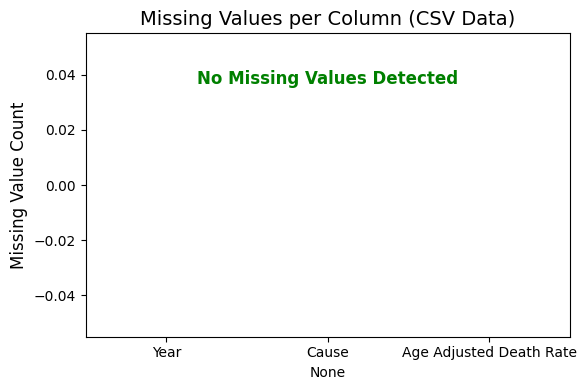

Number of duplicated rows in CSV dataset: 0


In [44]:
# 4.2 Missing Value Checks

import matplotlib.pyplot as plt
import seaborn as sns

missing_counts = df_csv.isnull().sum()
duplicate_count = df_csv.duplicated().sum()

plt.figure(figsize=(6,4))

sns.barplot(x=missing_counts.index,
            y=missing_counts.values,
            color="steelblue")

if missing_counts.sum() == 0:
    plt.text(0.5, 0.85,
             "No Missing Values Detected",
             ha='center', va='center',
             transform=plt.gca().transAxes,
             fontsize=12, color="green",
             fontweight='bold')

plt.xticks(rotation=0, fontsize=10)
plt.ylabel("Missing Value Count", fontsize=12)
plt.title("Missing Values per Column (CSV Data)", fontsize=14)
plt.tight_layout()
plt.show()

print(f"Number of duplicated rows in CSV dataset: {duplicate_count}")

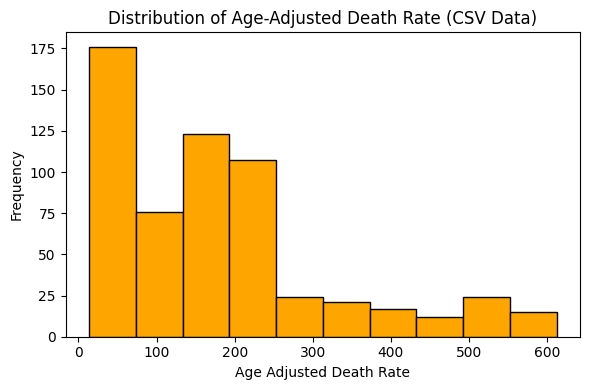

In [45]:
# 4.3 Distribution Checks (Histogram)

plt.figure(figsize=(6,4))
plt.hist(df_csv["Age Adjusted Death Rate"], bins=10, color="orange", edgecolor="black")
plt.title("Distribution of Age-Adjusted Death Rate (CSV Data)")
plt.xlabel("Age Adjusted Death Rate")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [46]:
# 4.4 Range & Logic Validation Checks

rate = df_csv["Age Adjusted Death Rate"]

Q1, Q3 = rate.quantile([0.25, 0.75])
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df_csv[(rate < lower) | (rate > upper)]
print("Outliers in Age Adjusted Death Rate (CSV):")
print(outliers if not outliers.empty else "  No outliers detected")


negative_rates = df_csv[rate < 0]
print("\nRows with negative Age Adjusted Death Rate:")
print(negative_rates if not negative_rates.empty else "  None (all values are non-negative)")

Outliers in Age Adjusted Death Rate (CSV):
     Year                    Cause  Age Adjusted Death Rate
28   1928            Heart Disease                    478.9
29   1929            Heart Disease                    476.2
32   1932            Heart Disease                    482.8
33   1933            Heart Disease                    483.8
34   1934            Heart Disease                    502.9
35   1935            Heart Disease                    506.8
36   1936            Heart Disease                    546.2
37   1937            Heart Disease                    538.8
38   1938            Heart Disease                    528.9
39   1939            Heart Disease                    534.5
40   1940            Heart Disease                    558.5
41   1941            Heart Disease                    537.9
42   1942            Heart Disease                    531.7
43   1943            Heart Disease                    567.5
44   1944            Heart Disease                    541

In [47]:
# 4.5 Exception Handling & Validation Functions

def validate_csv_dataframe(df):
    try:
        required_cols = ["Year", "Cause", "Age Adjusted Death Rate"]
        missing_cols = [c for c in required_cols if c not in df.columns]
        if missing_cols:

            raise KeyError(f"Missing required columns: {missing_cols}")


        if df["Age Adjusted Death Rate"].isnull().any():
            print("Warning: CSV has missing values in Age Adjusted Death Rate.")
        elif (df["Age Adjusted Death Rate"] < 0).any():
            print("Warning: CSV has negative Age Adjusted Death Rate values.")
        else:
            print("CSV validation passed: columns and basic logic look OK.")

    except KeyError as e:
        print("Validation error:", e)
    except Exception as e:

        print("Unexpected error during CSV validation:", e)

validate_csv_dataframe(df_csv)

CSV validation passed: columns and basic logic look OK.


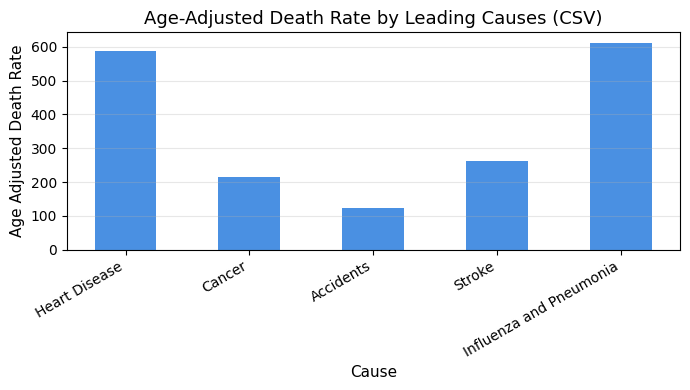

In [41]:
# 5 Visualizations

# 5.1 CSV Data Visualization

plt.figure(figsize=(7,4))
plt.bar(df_csv["Cause"], df_csv["Age Adjusted Death Rate"],
        color="#4A90E2", width=0.5)

plt.title("Age-Adjusted Death Rate by Leading Causes (CSV)", fontsize=13)
plt.xlabel("Cause", fontsize=11)
plt.ylabel("Age Adjusted Death Rate", fontsize=11)

plt.xticks(rotation=30, ha='right', fontsize=10)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

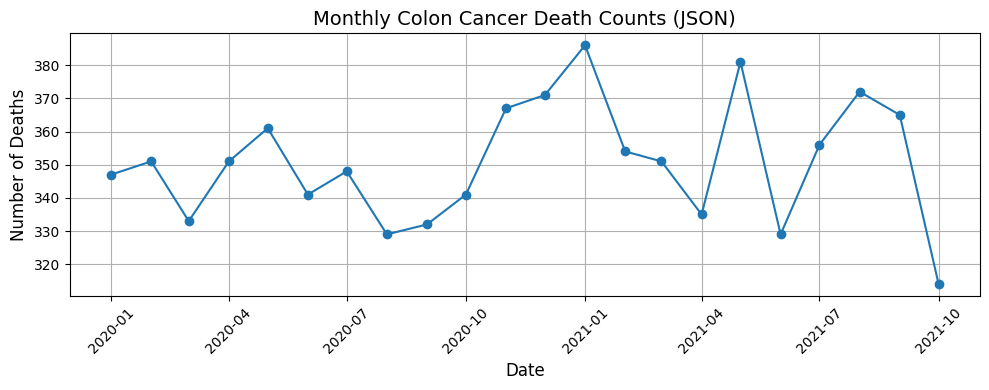

In [42]:
# 5.2 JSON Data Visualization

df_json_month = (
    df_json_clean
      .groupby(["year", "month"], as_index=False)["malignant_neoplasms_of_colon"]
      .sum())

df_json_month["date"] = pd.to_datetime(
    df_json_month["year"].astype(str) + "-" + df_json_month["month"].astype(str) + "-01")

plt.figure(figsize=(10,4))
plt.plot(df_json_month["date"],
         df_json_month["malignant_neoplasms_of_colon"],
         marker="o")

plt.title("Monthly Colon Cancer Death Counts (JSON)", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Number of Deaths", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

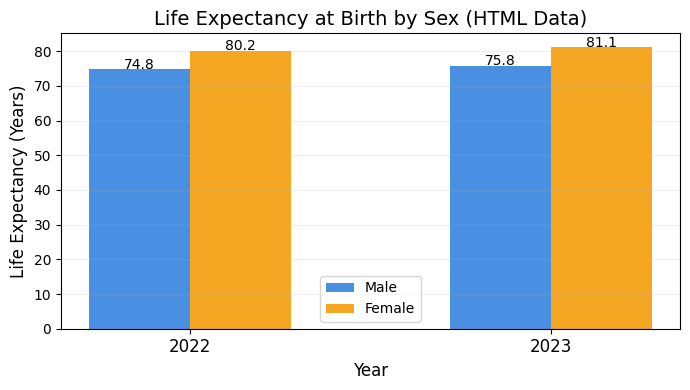

In [43]:
# 5.3 HTML Data Visualization

import matplotlib.pyplot as plt
import numpy as np

df_plot = df_html.sort_values("Year")

years = df_plot["Year"].astype(str)
male = df_plot["At_birth_male"]
female = df_plot["At_birth_female"]

x = np.arange(len(years))
width = 0.28

plt.figure(figsize=(7,4))

plt.bar(x - width/2, male, width, label="Male", color="#4A90E2")

plt.bar(x + width/2, female, width, label="Female", color="#F5A623")


for vals, offset in [(male, -width/2), (female, width/2)]:
    for i, v in enumerate(vals):
        plt.text(x[i] + offset, v + 0.1, f"{v:.1f}", ha='center', fontsize=10)

plt.xticks(x, years, fontsize=12)
plt.ylabel("Life Expectancy (Years)", fontsize=12)
plt.xlabel("Year", fontsize=12)
plt.title("Life Expectancy at Birth by Sex (HTML Data)", fontsize=14)

plt.legend()
plt.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

## 6 pipeline design
The mini health data warehouse developed in this project follows a clear and repeatable data pipeline designed to ensure consistency, data quality, and transparency. The process begins with data ingestion, where three different file formats—CSV, JSON, and HTML—are loaded using the appropriate pandas functions. This step reflects a realistic clinical environment in which hospitals receive data from multiple departments in heterogeneous formats.

Once the raw files are ingested, the data enters a cleaning and standardization stage. Here, column names are aligned, data types are converted, and formatting inconsistencies are removed. This step ensures that all datasets follow a unified schema, which is essential for downstream validation and analysis.

After initial cleaning, the data flows into a validation layer. The project implements several basic quality checks, including missing value detection, duplicate identification, outlier checks, and logical rules (for example, age-adjusted death rates must not be negative). Custom validation logic is wrapped in simple exception handling, allowing the system to surface errors without interrupting execution. This layer serves as a safeguard that prevents invalid or inconsistent data from contaminating the warehouse.

The next stage of the pipeline focuses on reshaping and integration. Although the public datasets used in this project are well-structured, this step prepares the data for future schema evolution, enabling pivoting, merging, or aligning datasets if additional years or clinical indicators were added.

The cleaned and validated data then moves into the visualization stage, where trends and data quality issues are presented through charts. These visual outputs provide immediate feedback on whether the pipeline produced reliable, consistent data. Finally, the pipeline concludes with documentation and governance steps, where the processing logic, validation results, and final dataset structure are recorded within the notebook. This ensures transparency, versioning, and reproducibility.

Overall, the pipeline is structured to be modular and automatable. In a real hospital setting, it could be scheduled to run daily or triggered when new departmental files are uploaded, making the workflow both scalable and maintainable.


### 6.1 Data Flow

This project uses a simple but structured data pipeline to process health data from multiple sources.  
The overall data flow can be described as the following:

```text
┌──────────────────────────────┐
│   Raw Data (CSV/JSON /HTML)  │
└───────────────┬──────────────┘
                ▼
┌──────────────────────────────┐
│  Step 1                      │
│   Data Ingestion & Parsing   │  
└───────────────┬──────────────┘
                ▼
┌──────────────────────────────┐
│  Step 2                      │
│         Initial Data         │
│    Exploration & Profiling   │               
└───────────────┬──────────────┘
                ▼
┌──────────────────────────────┐
│  Step 3                      │
│         Data Cleaning,       │
│ Standardization & Reshaping  │
└───────────────┬──────────────┘
                ▼
┌──────────────────────────────┐
│  Step 4                      │
│      Data Quality Checks,    │
│    Validation & Diagnostics  │
└───────────────┬──────────────┘
                ▼
┌──────────────────────────────┐
│  Step 5                      │
│Visualization & Final Outputs │
└──────────────────────────────┘

This diagram summarizes the full end-to-end pipeline.

---
### 6.2 Automated and Repeatable Workflow

Each step in this pipeline is designed to be repeatable and automated.

- **Step 1: Data Ingestion & Parsing**  
  This step handles reading raw data from CSV, JSON, and HTML sources and loading them into Pandas DataFrames. By keeping ingestion logic separate, the pipeline can easily adapt if the data source or file location changes.

- **Step 2: Initial Data Exploration & Profiling**  
  Basic exploration (e.g., shape, data types, summary statistics) is always performed immediately after ingestion. This ensures that incoming data matches expectations and provides a quick sanity check before further processing.


- **Step 3: Data Cleaning, Standardization & Reshaping**  
  Data is cleaned and standardized into a consistent structure, and reshaping is applied to prepare the data for analysis. Doing this in a single step ensures downstream processes always receive clean, well-formatted data.

- **Step 4: Data Quality Checks, Validation & Diagnostics**  
  Validation checks such as missing values, duplicates, outliers, and logical errors are applied before final analysis. This step acts as a safety gate, preventing invalid data from propagating further.


  - **Step 5: Visualization**  
  Once data passes validation, visualizations are generated as the final output. This step can be reused for reporting, dashboards, or further analysis.
  

Overall, this structure allows the pipeline to be rerun consistently whenever new data becomes available.

---

### 6.3 Scheduling and Automation Options

This pipeline can be easily automated and scheduled in several ways:

- **Scheduled batch runs**
  The pipeline can be set to run daily, weekly, or monthly using task schedulers such as cron jobs or workflow tools.

- **Event-based triggers**
The pipeline can automatically run when new data files (CSV, JSON, or HTML) are added or updated.

- **Script or notebook execution**
The notebook can be converted into a Python script and executed as part of an automated workflow.


These options make the pipeline suitable for both academic assignments and real-world data processing scenarios.

---

## 7. Data Governance Plan

**Versioning strategy:** Raw source files are kept unchanged and saved with a simple version tag or date. Cleaning outputs follow the same naming so results are reproducible.

**Roles & responsibilities:** The **Data Owner** defines the official source and update cadence, the **Data Steward** maintains data quality rules and schema standards, and the **Analyst/Engineer** maintains the pipeline code and validation logic.

**Change tracking:** Each run records basic metadata (row count, column list, key summary stats) and prints validation logs (missing values, duplicates, outliers, schema mismatches). Notebook outputs serve as an audit trail for what changed and when.

---
Overall, this governance approach provides sufficient control and transparency for a small analytical pipeline while remaining lightweight and easy to maintain.

## 8. Data Lineage & Documentation

### 8.1 Data Lineage (Source → Transform → Output)

This project uses three public data sources and applies standardized transformations to produce clean, validated datasets and visual outputs.

**Source 1: CSV (Age-adjusted death rates)**  
- **Origin:** CDC / NCHS dataset (CSV download)  
- **Ingested as:** `df_csv`  
- **Key transforms:** select relevant columns, type conversion to numeric, optional reshape to long format (`melt`)  
- **Output:** `df_csv_clean`, `df_long`, and CSV-based bar chart + histogram

**Source 2: JSON (Monthly cancer death counts)**  
- **Origin:** Public API / JSON dataset  
- **Ingested as:** `df_json_raw` → `df_json_clean`  
- **Key transforms:** filter to relevant measures, convert types, derive date fields, group by year/month  
- **Output:** `df_json_clean` and time-series visualization

**Source 3: HTML (Life expectancy table)**  
- **Origin:** Public HTML table source  
- **Ingested as:** `df_html_raw` → `df_html_clean`  
- **Key transforms:** parse table, convert numeric columns, standardize labels, sort by year  
- **Output:** `df_html_clean` and gender comparison chart

**Validation gate (applies to all datasets):** missingness, duplicates, range/logic checks, outlier checks (IQR), and exception handling.

---

### 8.2 Project Documentation (Tools + Structure)

**Tools used**
- Python (Google Colab)
- pandas (data ingestion/cleaning)
- matplotlib (visualization)
- requests / BeautifulSoup (HTML ingestion)

**Notebook structure**
- **Step 1–3:** ingestion, exploration, cleaning/reshaping  
- **Step 4:** data quality checks & validation  
- **Step 5:** visualizations  
- **Step 6-8:** pipeline design, governance, lineage, executive summary  

This structure makes the workflow easy to rerun and easy to audit.

---